# Predictive Maintenance & Anomaly Detection
# MetroPT-3

**Dataset:** MetroPT-3 (UCI Machine Learning Repository) — real multivariate time-series sensor data (pressure, temperature, motor current, air intake valves) from a metro train's Air Production Unit, with documented failure events.

## Project Recap & Roadmap

### What we've done so far
1. **Loaded & cleaned** the MetroPT-3 sensor data (Air Production Unit on a metro train),
   and documented the 4 known failure windows reported alongside the dataset.
2. **Resampled to 1-minute frequency** and investigated data gaps — found that some gaps
   coincide with a documented maintenance event (failure #3), and that gaps do *not*
   simply overlap the other 3 failures.
3. **Engineered features**: 1-hour rolling mean/std over 7 continuous sensors, fit only on
   "normal" (non-failure) periods to avoid leakage into anything trained downstream.
4. **Reduced dimensionality with PCA** (90% variance), again fit only on normal data,
   transformed separately for scoring vs. training to keep the leakage discipline consistent.
5. **Trained an Isolation Forest** on the PCA-transformed normal data and scored the full
   timeline — got 4/4 recall against the documented failures with this feature set.
6. **Investigated the longest anomaly episode** (Jun 22–25, ~62.5h) using plain pandas
   checks (timestamp continuity, per-sensor variance vs. baseline, % of unchanged
   consecutive readings) and confirmed it's a **frozen-sensor artifact**, not a genuine
   anomaly — all 7 sensors flat-lined simultaneously while still being timestamped.
7. **Generalizing that check to every episode** (in progress): flagging and excluding
   frozen/flat windows across the whole `episodes` table.

8. **Finished the frozen-window cleanup** — apply the flag, rebuild `episodes_clean`, and
   recompute recall/precision on the cleaned table so the 4/4 recall claim has a
   trustworthy precision number next to it.

### 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.float_format', lambda x: f'{x:.10f}')

### 2. Load Data

In [3]:
df = pd.read_csv('data_input/metropt_3_dataset/MetroPT3(AirCompressor).csv')  # Load your dataset here

In [4]:
df.columns

Index(['Unnamed: 0', 'timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure',
       'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric',
       'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level',
       'Caudal_impulses'],
      dtype='str')

In [5]:
# Failures Table

failure_data = [
    {'nr': '#1', 'start_time': '2020-04-18 00:00:00', 'end_time': '2020-04-18 23:59:00',
     'failure': 'Air Leak', 'severity': 'High stress', 'report': None},
    {'nr': '#2', 'start_time': '2020-05-29 23:30:00', 'end_time': '2020-05-30 06:00:00',
     'failure': 'Air Leak', 'severity': 'High stress', 'report': 'Maintenance on 30Apr at 12:00'},
    {'nr': '#3', 'start_time': '2020-06-05 10:00:00', 'end_time': '2020-06-07 14:30:00',
     'failure': 'Air Leak', 'severity': 'High stress', 'report': 'Maintenance on 8Jun at 16:00'},
    {'nr': '#4', 'start_time': '2020-07-15 14:30:00', 'end_time': '2020-07-15 19:00:00',
     'failure': 'Air Leak', 'severity': 'High stress', 'report': 'Maintenance on 16Jul at 00:00'},
]

df_failures = pd.DataFrame(failure_data)
df_failures['start_time'] = pd.to_datetime(df_failures['start_time'])
df_failures['end_time'] = pd.to_datetime(df_failures['end_time'])

df_failures

,nr,start_time,end_time,failure,severity,report
0,#1,2020-04-18 00:00:00,2020-04-18 23:59:00,Air Leak,High stress,NaN
1,#2,2020-05-29 23:30:00,2020-05-30 06:00:00,Air Leak,High stress,Maintenance on 30Apr at 12:00
2,#3,2020-06-05 10:00:00,2020-06-07 14:30:00,Air Leak,High stress,Maintenance on 8Jun at 16:00
3,#4,2020-07-15 14:30:00,2020-07-15 19:00:00,Air Leak,High stress,Maintenance on 16Jul at 00:00


In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [7]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [8]:
df = df.set_index('timestamp')

In [9]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0000000000,1.3678259663,3.2509296807,-0.0320000000,-0.0140000000,-0.0120000000,-0.0100000000,10.6760000000
TP3,1516948.0000000000,8.9846107012,0.6390950863,0.7300000000,8.4920000000,8.9600000000,9.4920000000,10.3020000000
H1,1516948.0000000000,7.5681549005,3.3331995653,-0.0360000000,8.2540000000,8.7840000000,9.3740000000,10.2880000000
DV_pressure,1516948.0000000000,0.0559561897,0.3824015460,-0.0320000000,-0.0220000000,-0.0200000000,-0.0180000000,9.8440000000
Reservoirs,1516948.0000000000,8.9852334437,0.6383070419,0.7120000000,8.4940000000,8.9600000000,9.4920000000,10.3000000000
Oil_temperature,1516948.0000000000,62.6441817386,6.5162610894,15.4000000000,57.7750000000,62.7000000000,67.2500000000,89.0500000000
Motor_current,1516948.0000000000,2.0501708035,2.3020534139,0.0200000000,0.0400000000,0.0450000000,3.8075000000,9.2950000000
COMP,1516948.0000000000,0.8369568370,0.3694051704,0.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000
DV_eletric,1516948.0000000000,0.1606106472,0.3671715622,0.0000000000,0.0000000000,0.0000000000,0.0000000000,1.0000000000
Towers,1516948.0000000000,0.9198482743,0.2715280375,0.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000


### 3. Resample Data

In [10]:

df_resampled = df.resample('1min').mean()
df_resampled.head()

,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
timestamp,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.0122857143,9.3274285714,9.3111428571,-0.0228571429,9.3280000000,53.5214285714,0.0403571429,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
2020-02-01 00:01:00,-0.0130000000,9.2600000000,9.2433333333,-0.0233333333,9.2596666667,53.4208333333,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
2020-02-01 00:02:00,-0.0126666667,9.1983333333,9.1820000000,-0.0223333333,9.1990000000,53.3250000000,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
2020-02-01 00:03:00,-0.0123333333,9.1366666667,9.1206666667,-0.0226666667,9.1366666667,53.2000000000,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
2020-02-01 00:04:00,-0.0130000000,9.0756666667,9.0600000000,-0.0230000000,9.0756666667,53.1291666667,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000


In [11]:
df_resampled.dropna(inplace=True)

In [12]:
df_resampled.reset_index(inplace=True)

In [13]:
df_resampled.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.0122857143,9.3274285714,9.3111428571,-0.0228571429,9.3280000000,53.5214285714,0.0403571429,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
1,2020-02-01 00:01:00,-0.0130000000,9.2600000000,9.2433333333,-0.0233333333,9.2596666667,53.4208333333,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
2,2020-02-01 00:02:00,-0.0126666667,9.1983333333,9.1820000000,-0.0223333333,9.1990000000,53.3250000000,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
3,2020-02-01 00:03:00,-0.0123333333,9.1366666667,9.1206666667,-0.0226666667,9.1366666667,53.2000000000,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
4,2020-02-01 00:04:00,-0.0130000000,9.0756666667,9.0600000000,-0.0230000000,9.0756666667,53.1291666667,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000


In [14]:
df_resampled = df_resampled.set_index('timestamp', drop=False)

In [15]:
df_resampled.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 252720 entries, 2020-02-01 00:00:00 to 2020-09-01 03:59:00
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   timestamp        252720 non-null  datetime64[us]
 1   TP2              252720 non-null  float64       
 2   TP3              252720 non-null  float64       
 3   H1               252720 non-null  float64       
 4   DV_pressure      252720 non-null  float64       
 5   Reservoirs       252720 non-null  float64       
 6   Oil_temperature  252720 non-null  float64       
 7   Motor_current    252720 non-null  float64       
 8   COMP             252720 non-null  float64       
 9   DV_eletric       252720 non-null  float64       
 10  Towers           252720 non-null  float64       
 11  MPG              252720 non-null  float64       
 12  LPS              252720 non-null  float64       
 13  Pressure_switch  252720 non-null  float64       
 1

In [16]:
time_diffs = df_resampled['timestamp'].diff()

In [17]:
time_diffs

timestamp
2020-02-01 00:00:00               NaT
2020-02-01 00:01:00   0 days 00:01:00
2020-02-01 00:02:00   0 days 00:01:00
2020-02-01 00:03:00   0 days 00:01:00
2020-02-01 00:04:00   0 days 00:01:00
                            ...      
2020-09-01 03:55:00   0 days 00:01:00
2020-09-01 03:56:00   0 days 00:01:00
2020-09-01 03:57:00   0 days 00:01:00
2020-09-01 03:58:00   0 days 00:01:00
2020-09-01 03:59:00   0 days 00:01:00
Name: timestamp, Length: 252720, dtype: timedelta64[us]

In [18]:
time_diffs.describe()

count                    252719
mean     0 days 00:01:12.877543
std      0 days 00:12:48.646449
min             0 days 00:01:00
25%             0 days 00:01:00
50%             0 days 00:01:00
75%             0 days 00:01:00
max             2 days 00:02:00
Name: timestamp, dtype: object

In [19]:
# Do gaps overlap the failures? 
threshold = pd.Timedelta(hours=1)
gap_starts = df_resampled.index.to_series().shift(1)[time_diffs > threshold]
gap_ends = df_resampled.index.to_series()[time_diffs > threshold]
gap_sizes = time_diffs[time_diffs > threshold]

df_gaps = pd.DataFrame({'gap_start': gap_starts.values, 'gap_end': gap_ends.values, 'gap_size': gap_sizes.values})
df_gaps.sort_values('gap_start')

,gap_start,gap_end,gap_size
0,2020-02-01 19:40:00,2020-02-01 23:15:00,0 days 03:35:00
1,2020-02-01 23:20:00,2020-02-02 04:34:00,0 days 05:14:00
2,2020-02-05 01:07:00,2020-02-05 04:28:00,0 days 03:21:00
3,2020-02-06 02:07:00,2020-02-06 07:52:00,0 days 05:45:00
4,2020-02-06 19:16:00,2020-02-06 23:33:00,0 days 04:17:00
...,...,...,...
154,2020-08-29 01:08:00,2020-08-29 04:55:00,0 days 03:47:00
155,2020-08-30 00:41:00,2020-08-30 04:26:00,0 days 03:45:00
156,2020-08-31 00:30:00,2020-08-31 01:49:00,0 days 01:19:00
157,2020-08-31 20:15:00,2020-09-01 00:37:00,0 days 04:22:00


In [20]:
df_failures

,nr,start_time,end_time,failure,severity,report
0,#1,2020-04-18 00:00:00,2020-04-18 23:59:00,Air Leak,High stress,NaN
1,#2,2020-05-29 23:30:00,2020-05-30 06:00:00,Air Leak,High stress,Maintenance on 30Apr at 12:00
2,#3,2020-06-05 10:00:00,2020-06-07 14:30:00,Air Leak,High stress,Maintenance on 8Jun at 16:00
3,#4,2020-07-15 14:30:00,2020-07-15 19:00:00,Air Leak,High stress,Maintenance on 16Jul at 00:00


In [21]:
overlaps = []
for _, gap in df_gaps.iterrows():
    for _, fail in df_failures.iterrows():
        if gap['gap_start'] <= fail['end_time'] and fail['start_time'] <= gap['gap_end']:
            overlaps.append({
                'gap_start': gap['gap_start'],
                'gap_end': gap['gap_end'],
                'failure_nr': fail['nr'],
                'failure_start': fail['start_time'],
                'failure_end': fail['end_time']
            })

df_overlaps = pd.DataFrame(overlaps)
df_overlaps

,gap_start,gap_end,failure_nr,failure_start,failure_end
0,2020-06-06 15:55:00,2020-06-06 19:42:00,#3,2020-06-05 10:00:00,2020-06-07 14:30:00
1,2020-06-07 14:19:00,2020-06-08 11:48:00,#3,2020-06-05 10:00:00,2020-06-07 14:30:00


Gaps do not overlap with failures #1, #2, or #4, but two significant gaps (totaling ~25 hours) occur during and immediately after failure #3, coinciding closely with its reported maintenance timestamp.


The second gap is the more interesting one: it starts at 14:19 on Jun 7 - just 11 minutes before the failure's documented end time of 14:30 - and then continues for another 21.5 hours, well past when the failure was supposedly "over." And recall the maintenance report for this failure says maintenance happened "8Jun at 16:00" - that's only about 4 hours after this gap ends (11:48 on Jun 8). That timeline lines up suspiciously well: it suggests the sensors may have gone dark as part of the same event that led to the eventual repair, and the "end time" in the failure report might reflect when someone stopped actively logging the issue, not necessarily when the physical problem (or the outage) actually resolved.

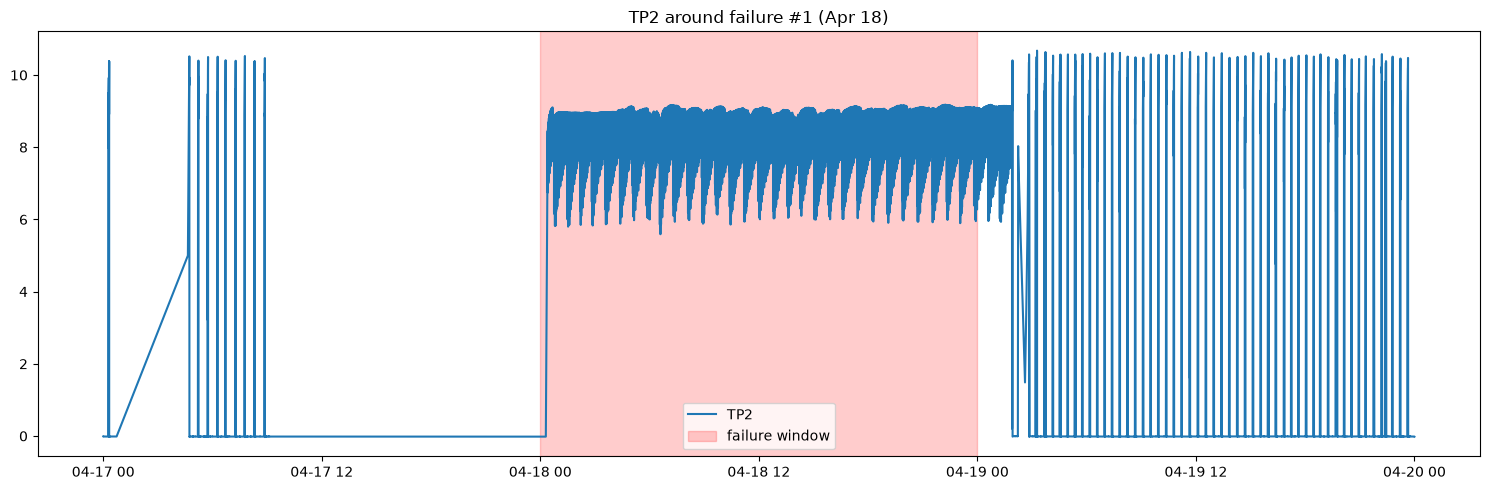

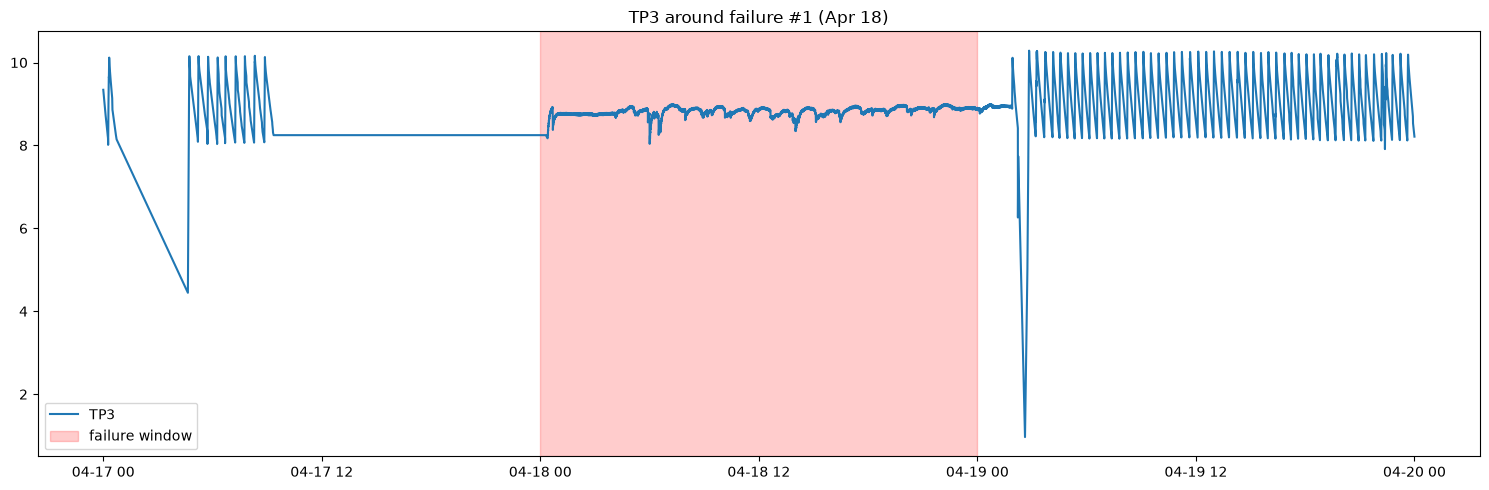

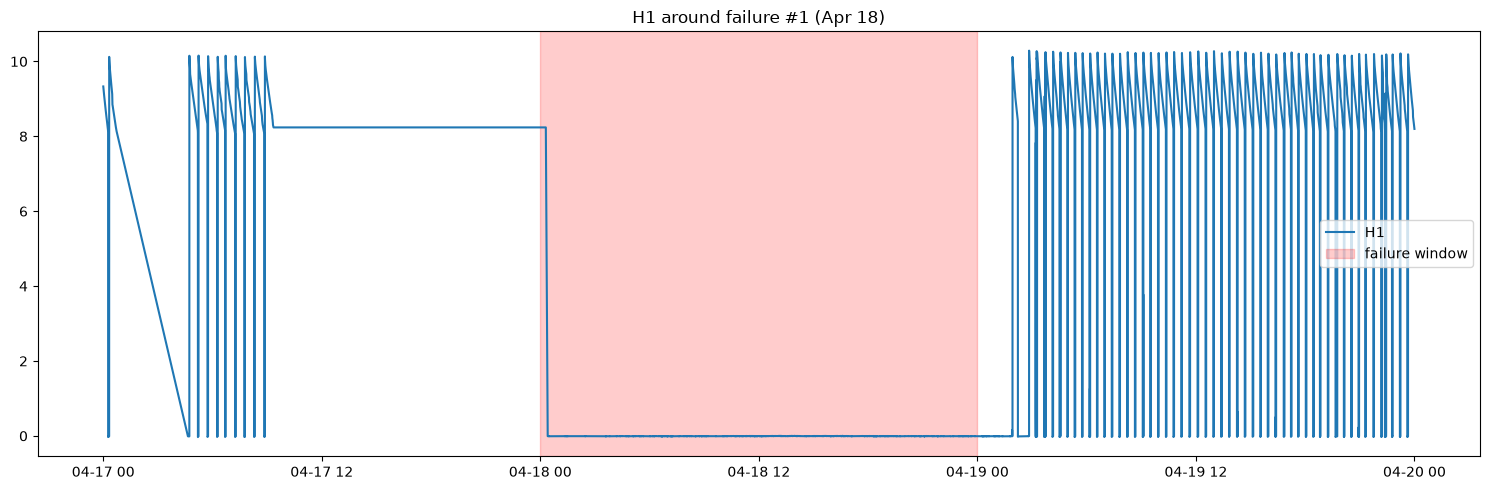

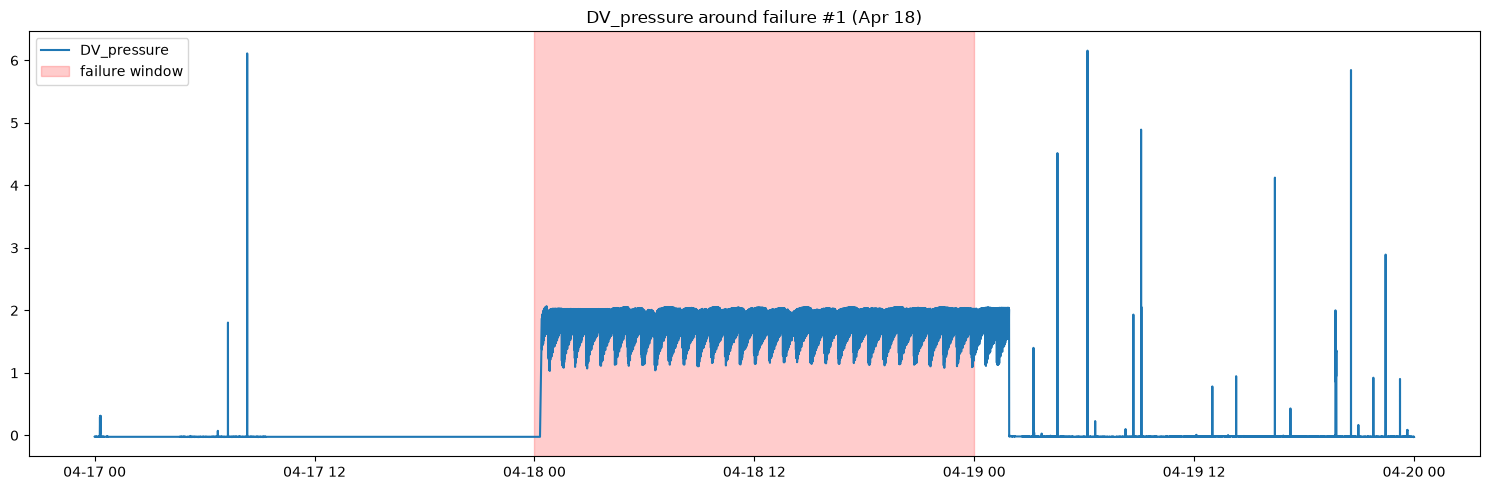

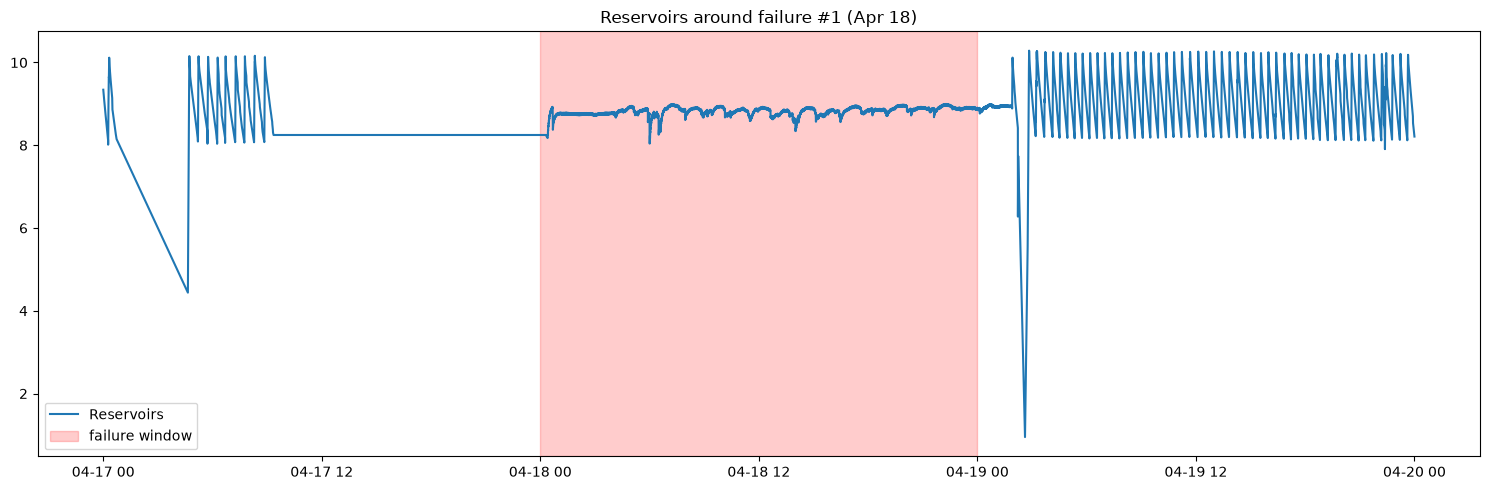

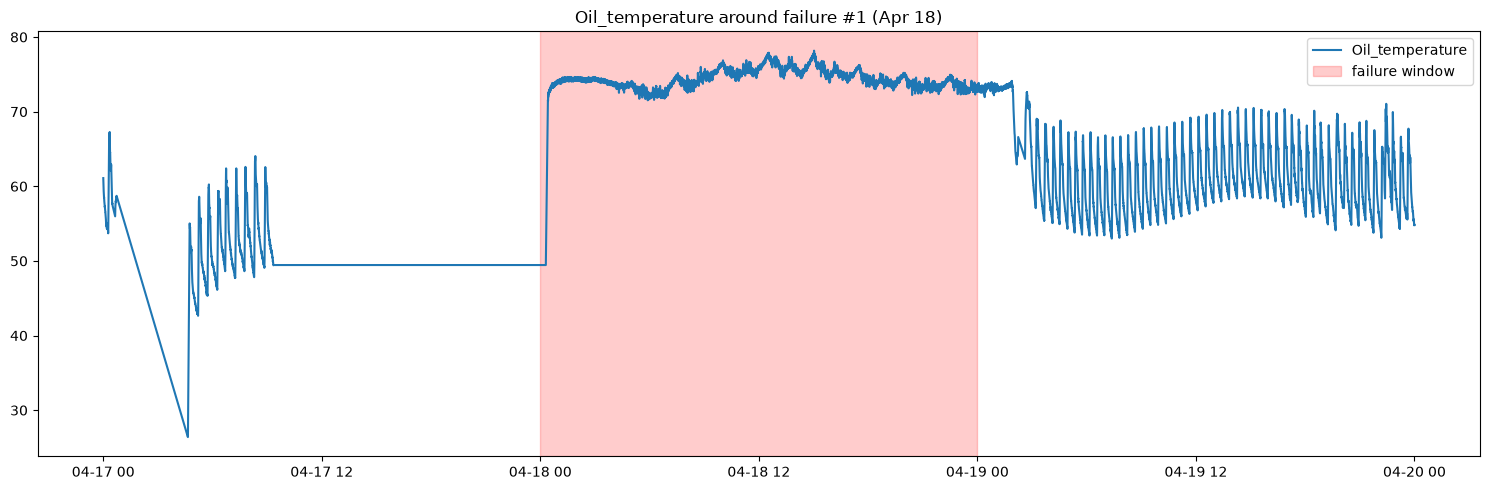

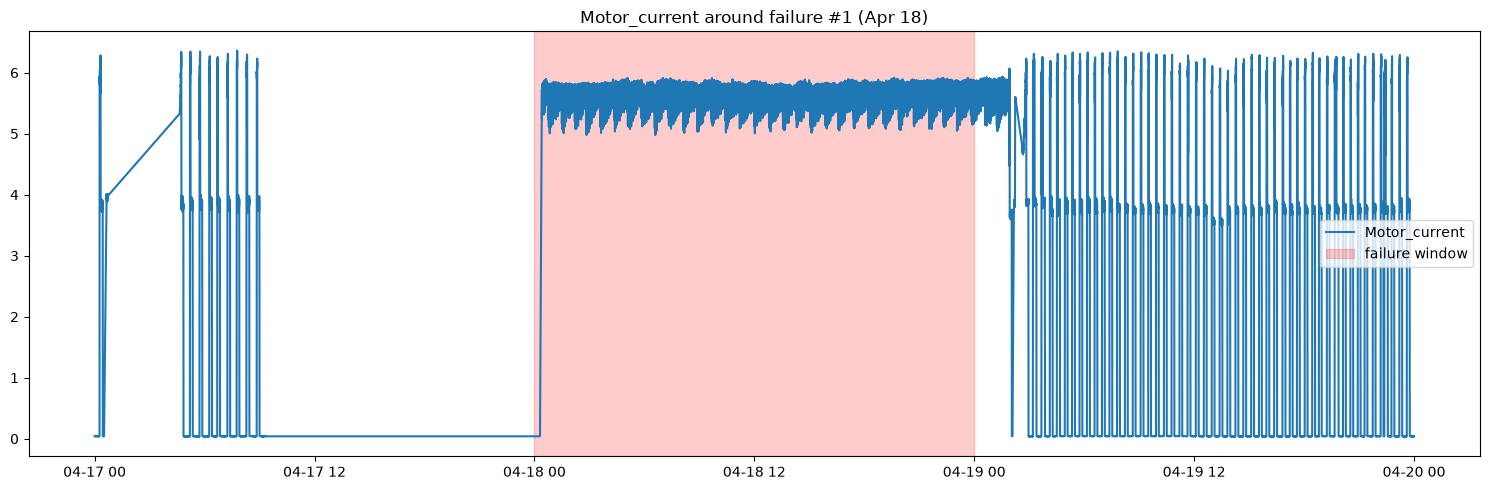

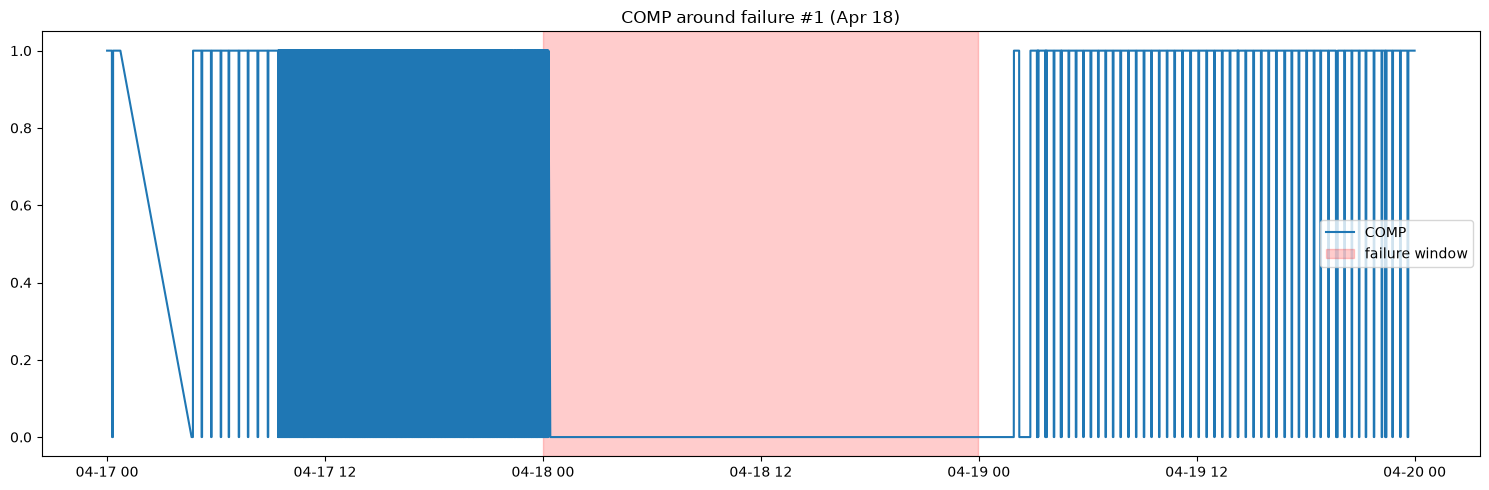

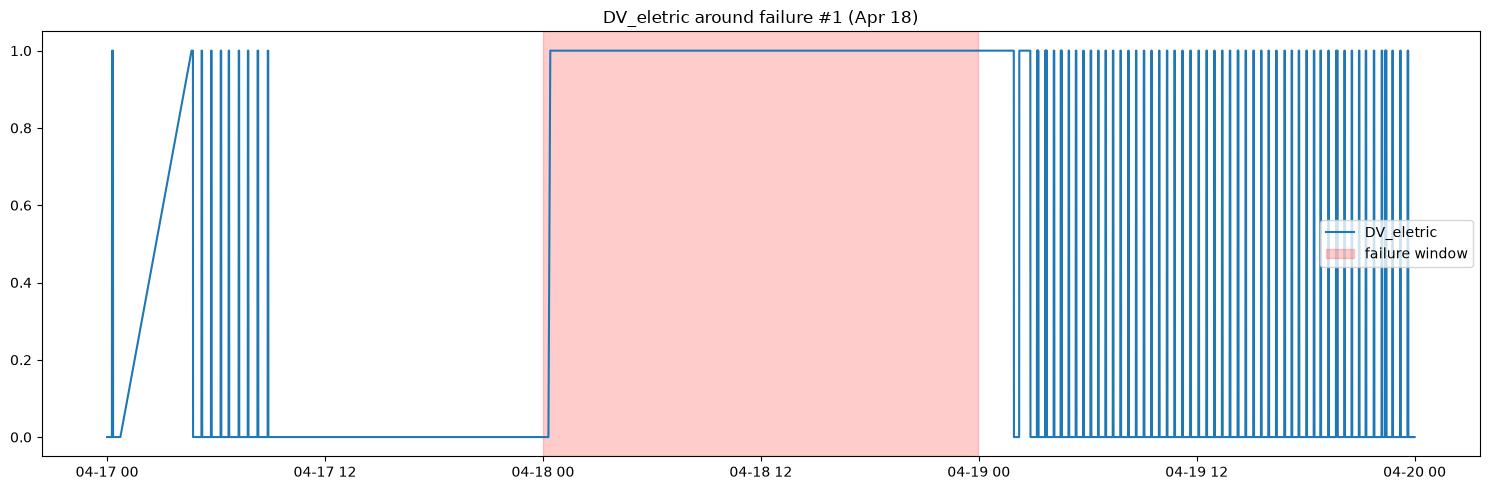

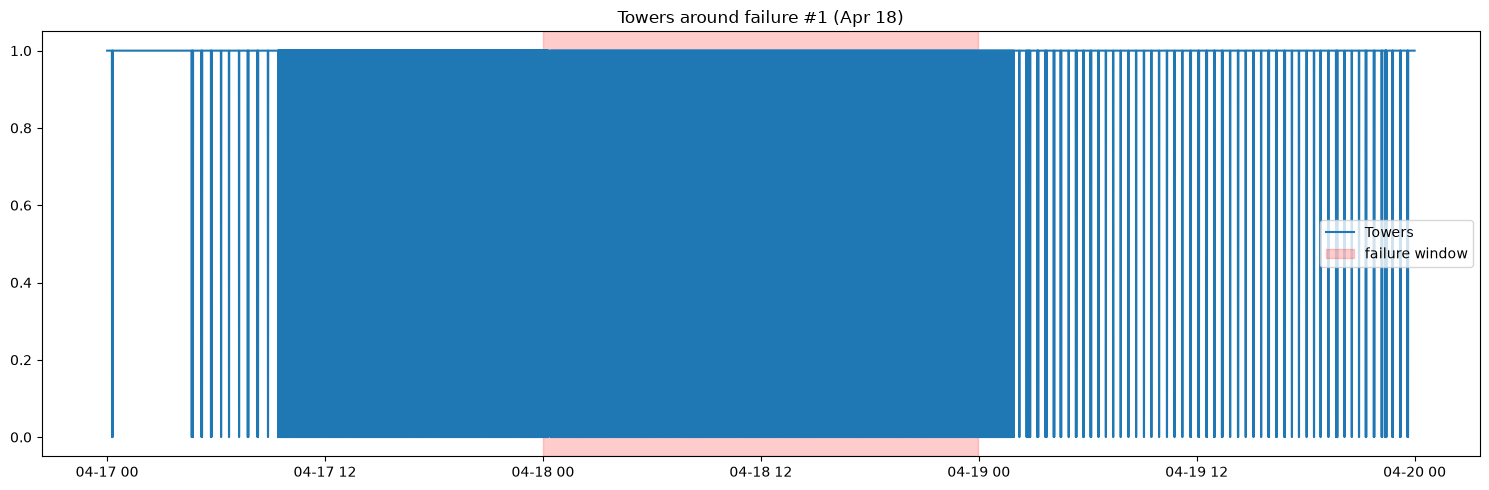

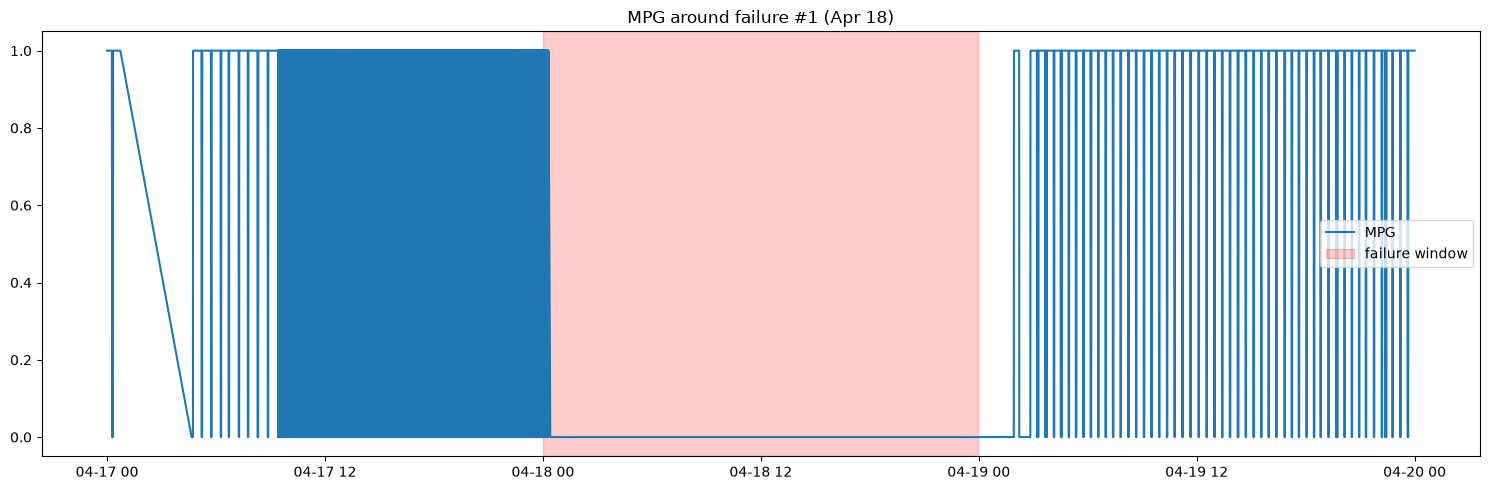

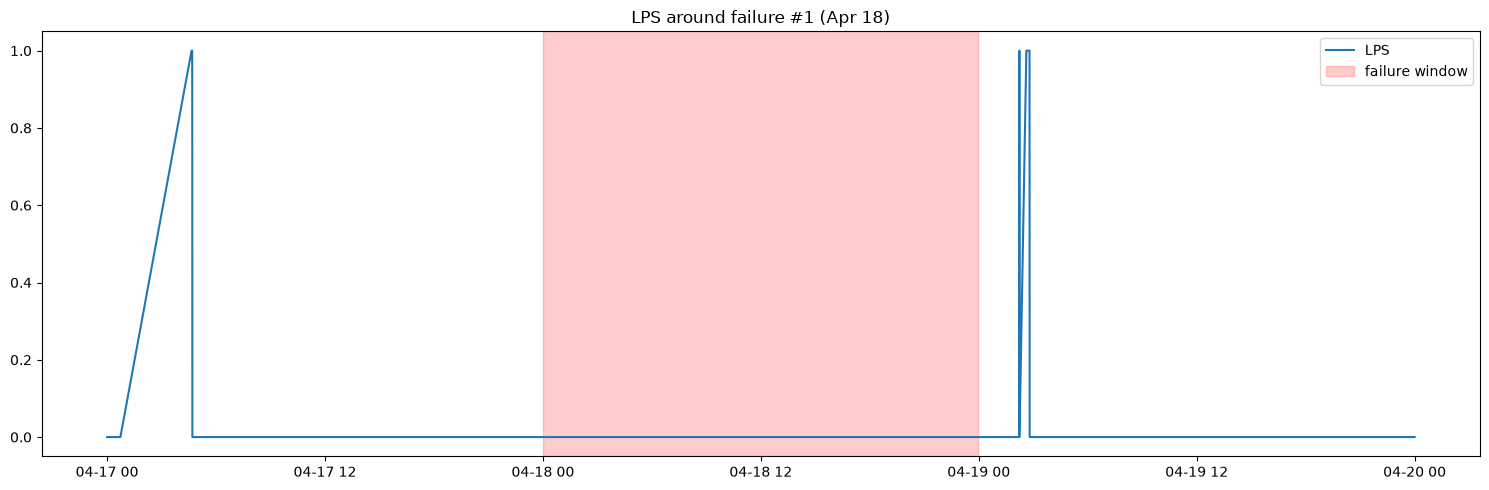

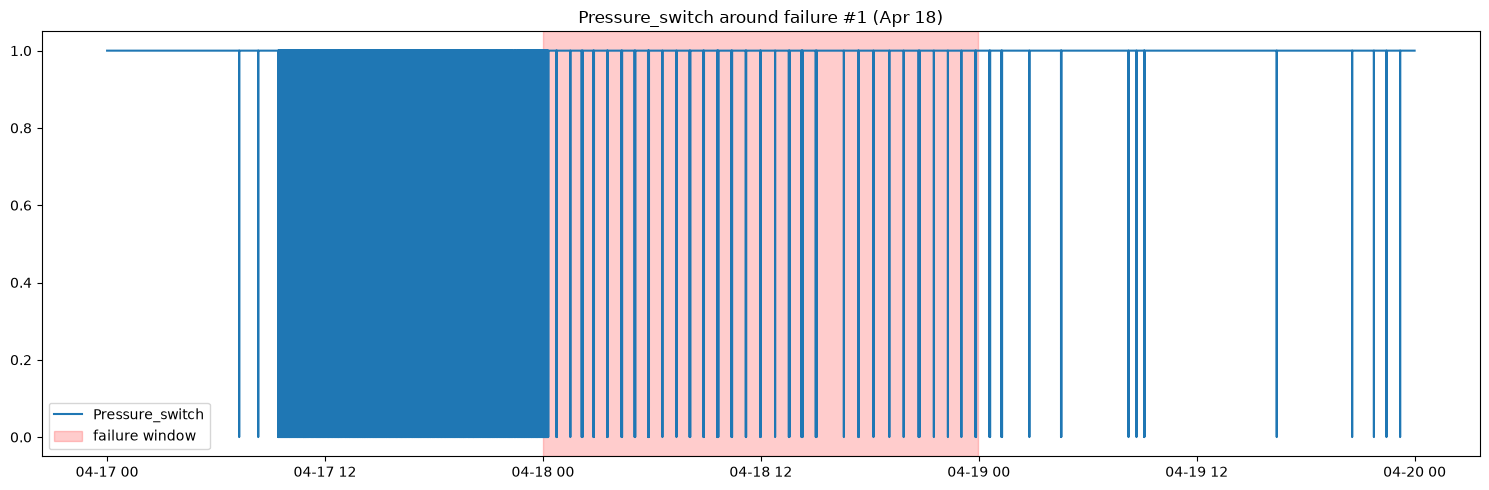

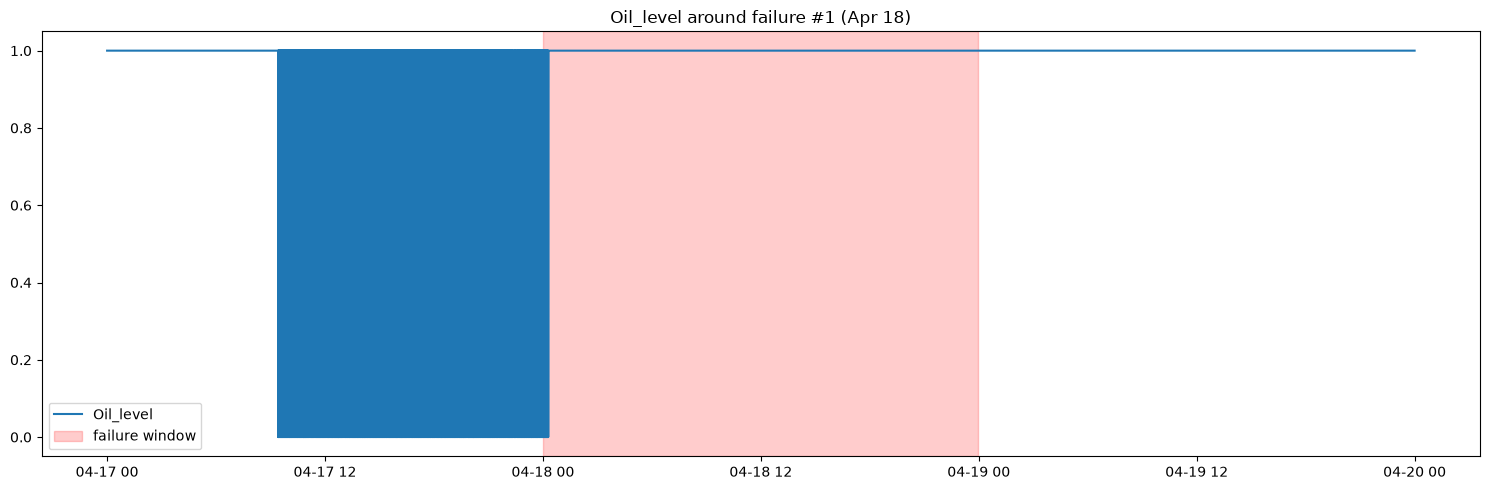

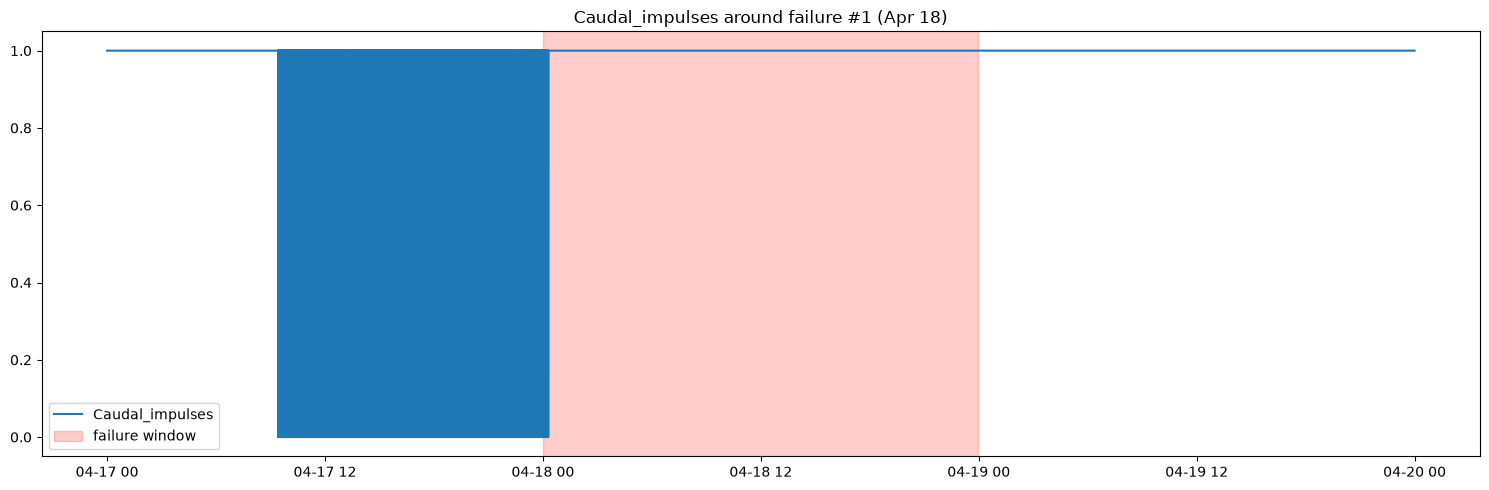

In [22]:
df_temp = df_temp = df.loc['2020-04-17':'2020-04-19']  

failure_start = pd.Timestamp('2020-04-18 00:00:00')
failure_end = pd.Timestamp('2020-04-18 23:59:00')

for col in df_temp.columns:
    if col != 'timestamp':
        plt.figure(figsize=(15, 5))
        plt.plot(df_temp.index, df_temp[col], label=col)
        plt.axvspan(failure_start, failure_end, color='red', alpha=0.2, label='failure window')
        plt.title(f'{col} around failure #1 (Apr 18)')
        plt.legend()
        plt.tight_layout()
        plt.show()

### 4. Principal Component Analysis

In [54]:
in_failure = pd.Series(False, index=df_resampled.index)
for _, fail in df_failures.iterrows():
    in_failure |= (df_resampled.index >= fail['start_time']) & (df_resampled.index <= fail['end_time'])

df_for_pca = df_resampled[~in_failure]

In [24]:
window = pd.Timedelta(hours=1)

feature_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']
digital_cols = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

rolling_features = pd.DataFrame(index=df_for_pca.index)

for col in feature_cols:
    rolling_features[f'{col}_mean'] = df_for_pca[col].rolling(window, min_periods=60).mean()
    rolling_features[f'{col}_std'] = df_for_pca[col].rolling(window, min_periods=60).std()

for col in digital_cols:
    rolling_features[f'{col}_activity'] = df_for_pca[col].rolling(window, min_periods=60).mean()

rolling_features = rolling_features.dropna()

In [25]:
window = pd.Timedelta(hours=1)

feature_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']
digital_cols = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

rolling_features_all = pd.DataFrame(index=df_resampled.index)

for col in feature_cols:
    rolling_features_all[f'{col}_mean'] = df_resampled[col].rolling(window, min_periods=60).mean()
    rolling_features_all[f'{col}_std'] = df_resampled[col].rolling(window, min_periods=60).std()

for col in digital_cols:
    rolling_features_all[f'{col}_activity'] = df_resampled[col].rolling(window, min_periods=60).mean()

rolling_features_all = rolling_features_all.dropna()

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipe = Pipeline([('scaler', StandardScaler()), ('reducer', PCA(n_components=0.9))])


In [27]:
pipe.fit(rolling_features) # fit only on normal data

print(len(pipe['reducer'].components_))

7


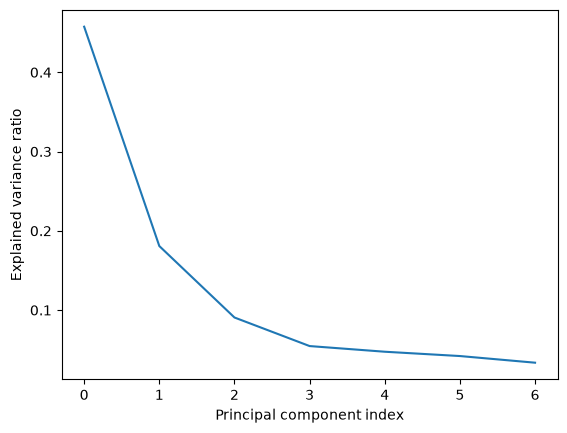

In [28]:
# Optimal number of components to explain 90% of the variance 
var = pipe['reducer'].explained_variance_ratio_
plt.plot(var)
plt.xlabel('Principal component index')
plt.ylabel('Explained variance ratio')
plt.show()


# Ref : https://scikit-learn.org/stable/common_pitfalls.html 
 "Common Pitfalls and Recommended Practices," explicitly names PCA as one of the transformations vulnerable to data leakage, alongside StandardScaler. Their stated rule: "it is important that these transformations are only learnt from the training data," achieved by using fit_transform on the training subset and transform (not fit) on everything else

 Sources:

- scikit-learn: Common Pitfalls and Recommended Practices
- On the Use of PCA for Diagnostics via Novelty Detection (PHM Society)
- Feature extraction for novelty detection as applied to fault detection in machinery (ScienceDirect)

In [29]:
# Version for scoring later: gaps out, failures still in
transformed_all = pipe.transform(rolling_features_all)

# Also keep the transformed "normal-only" version — you'll need this next,
# to fit Isolation Forest only on normal behavior
transformed_normal = pipe.transform(rolling_features)

In [30]:
#loadings = pd.DataFrame(pipe['reducer'].components_, columns=df_pca.columns, index=[f'PC{i+1}' for i in range(7)])
#print(loadings)

# Do later:  project your four known failure windows onto PC1 and PC2 specifically, and see whether they score visibly differently from normal operation — this is the direct, systematic answer to your very first question (finding failure similarity without eyeballing plots).

### 5. Predict Failures - Isolation Forest

In [31]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
iso_forest.fit(transformed_normal)

# Score everything, including the failure periods
anomaly_labels = iso_forest.predict(transformed_all)       # -1 = anomaly, 1 = normal
anomaly_scores = iso_forest.decision_function(transformed_all)  # continuous score; lower = more anomalous

In [32]:
rolling_features_all['anomaly_label'] = anomaly_labels
rolling_features_all['anomaly_score'] = anomaly_scores

In [33]:
print(len(rolling_features_all[rolling_features_all['anomaly_label'] == -1]))
print(len(rolling_features_all))

31670
237743


In [34]:
is_anom = rolling_features_all['anomaly_label'] == -1
anom_groups = (is_anom != is_anom.shift()).cumsum()

episodes = rolling_features_all[is_anom].groupby(anom_groups[is_anom]).apply(
    lambda g: pd.Series({'start': g.index.min(), 'end': g.index.max(), 'duration_rows': len(g)})
)
episodes = episodes.sort_values('duration_rows', ascending=False)
print(len(episodes))
episodes.head(15)

738


,start,end,duration_rows
anomaly_label,,,
870,2020-06-22 15:28:00,2020-06-25 05:08:00,3701
858,2020-06-05 09:51:00,2020-06-08 14:48:00,2785
846,2020-05-26 09:42:00,2020-05-28 03:16:00,2427
738,2020-04-17 09:47:00,2020-04-19 03:44:00,2366
832,2020-05-19 22:23:00,2020-05-21 06:57:00,1290
686,2020-03-28 07:24:00,2020-03-29 19:49:00,1272
744,2020-04-20 05:13:00,2020-04-21 01:16:00,1204
862,2020-06-12 02:30:00,2020-06-12 17:06:00,877
646,2020-03-12 00:24:00,2020-03-12 13:09:00,766


### 6. Quantify recall and precision against failures

For each anomaly episode, check whether it overlaps a documented failure window. From that: **recall** = how many of the 4 documented failures are caught by at least one episode; **precision** = of the anomaly episodes (and of the anomalous minutes), how many actually correspond to a documented failure vs. flag something else.

In [35]:
def find_matching_failure(start, end, df_failures):
    for _, fail in df_failures.iterrows():
        if start <= fail['end_time'] and fail['start_time'] <= end:
            return fail['nr']
    return None

episodes['matched_failure'] = episodes.apply(
    lambda row: find_matching_failure(row['start'], row['end'], df_failures), axis=1
)

episodes[episodes['matched_failure'].notnull()]

,start,end,duration_rows,matched_failure
anomaly_label,,,,
858,2020-06-05 09:51:00,2020-06-08 14:48:00,2785,#3
738,2020-04-17 09:47:00,2020-04-19 03:44:00,2366,#1
908,2020-07-15 10:50:00,2020-07-15 19:46:00,477,#4
848,2020-05-29 23:16:00,2020-05-30 06:51:00,456,#2


In [36]:
# Recall: how many documented failures are caught by at least one anomaly episode
matched_failures = sorted(episodes['matched_failure'].dropna().unique())
missed_failures = sorted(set(df_failures['nr']) - set(matched_failures))
print(f"Recall: {len(matched_failures)}/{len(df_failures)} documented failures matched -> "
      f"{len(matched_failures)/len(df_failures):.0%}")
print("Matched:", matched_failures)
print("Missed:", missed_failures)
print()

# Precision (episode-level): of all anomaly episodes, how many overlap a documented failure
n_matched_episodes = episodes['matched_failure'].notnull().sum()
n_total_episodes = len(episodes)
print(f"Episode-level precision: {n_matched_episodes}/{n_total_episodes} anomaly episodes "
      f"overlap a documented failure -> {n_matched_episodes/n_total_episodes:.1%}")

# Precision (time-level): of all anomalous minutes, how many fall inside a documented failure window
anomalous_rows = rolling_features_all[rolling_features_all['anomaly_label'] == -1]
in_doc_failure = pd.Series(False, index=anomalous_rows.index)
for _, fail in df_failures.iterrows():
    in_doc_failure |= (anomalous_rows.index >= fail['start_time']) & (anomalous_rows.index <= fail['end_time'])

n_tp_minutes = in_doc_failure.sum()
n_total_anom_minutes = len(anomalous_rows)
print(f"Time-level precision: {n_tp_minutes}/{n_total_anom_minutes} anomalous minutes fall inside "
      f"a documented failure window -> {n_tp_minutes/n_total_anom_minutes:.1%}")

Recall: 4/4 documented failures matched -> 100%
Matched: ['#1', '#2', '#3', '#4']
Missed: []

Episode-level precision: 4/738 anomaly episodes overlap a documented failure -> 0.5%
Time-level precision: 4724/31670 anomalous minutes fall inside a documented failure window -> 14.9%


4 for 4 recall, with the new feature set. That's a real improvement worth noting.

One thing needs direct follow-up before trusting this fully: Row 640, the single longest episode (Jun 22–25, 62.5 hours), is the exact same period we already investigated and found strong evidence was a data gap, not a real event. Every sensor sat perfectly flat when we plotted it. If it's showing up again here, that's concerning: either there's a partial/degraded logging issue in that window that slipped past the NaN-based gap filter (a sparse trickle of real readings rather than a clean gap), or something else is going on. This needs to be checked directly, not assumed.

In [37]:
# filter rolling_features_all for 2020-06-22 15:28:00	2020-06-25 05:08:00	

rolling_features_all_filtered = rolling_features_all.loc['2020-06-22 15:28:00':'2020-06-25 05:08:00']
rolling_features_all_filtered.groupby('anomaly_label')['anomaly_label'].count()

anomaly_label
-1    3701
Name: anomaly_label, dtype: int64

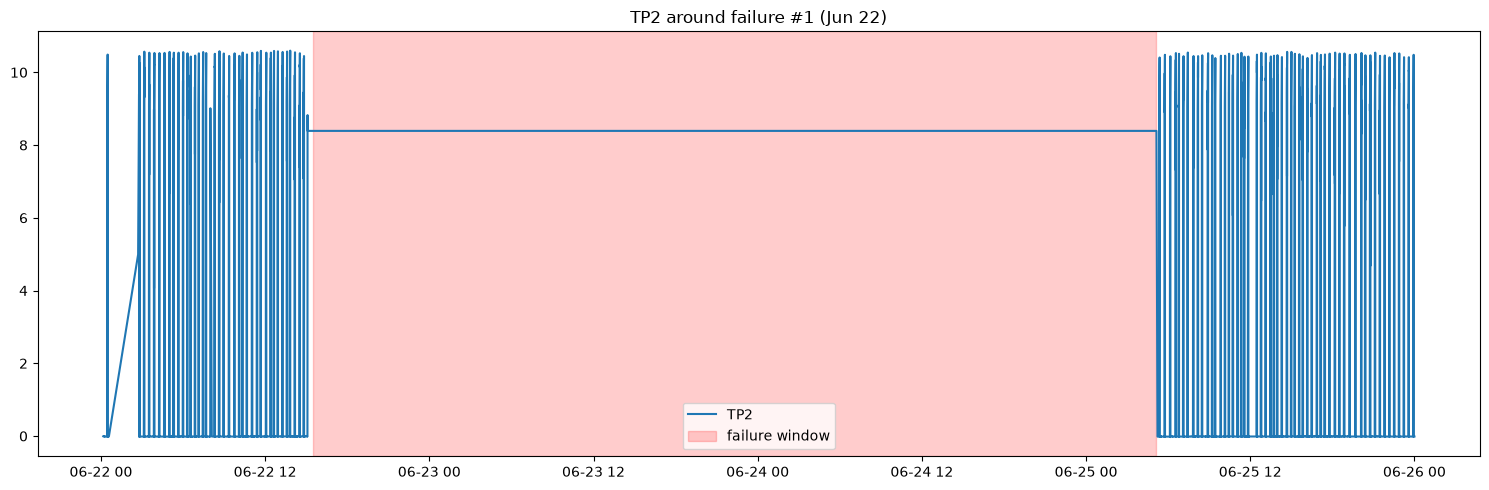

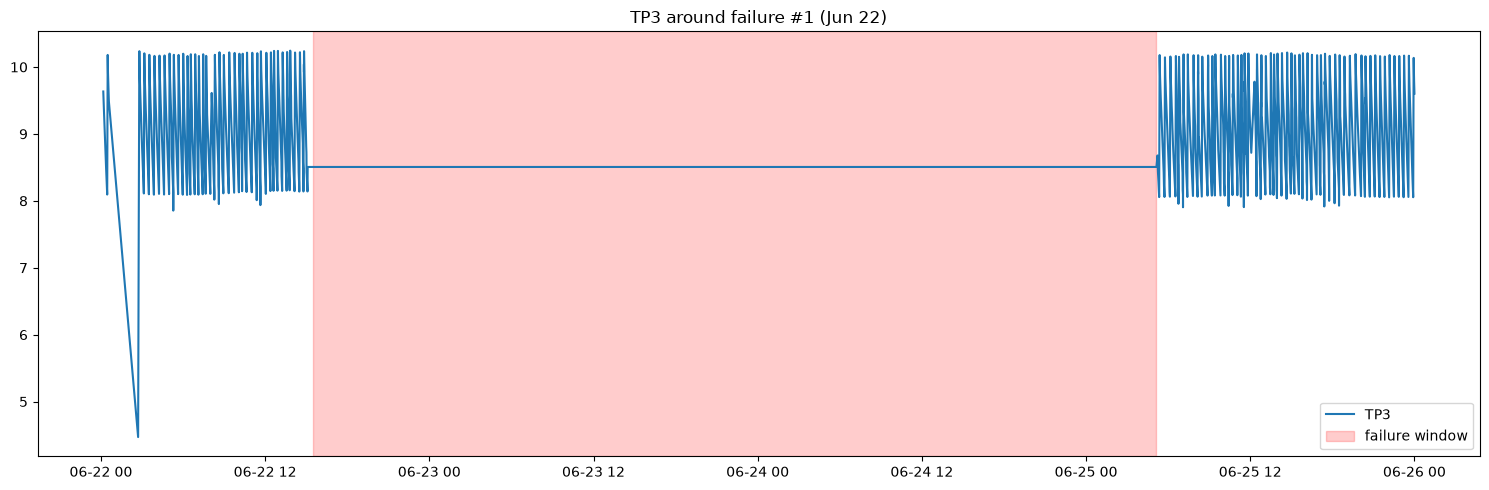

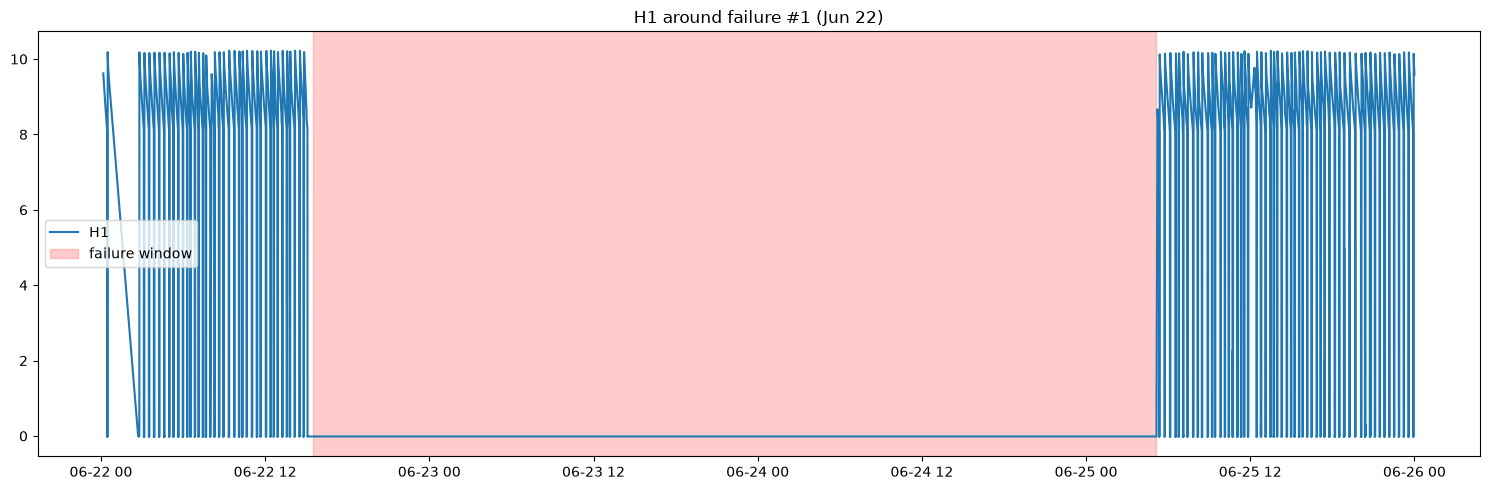

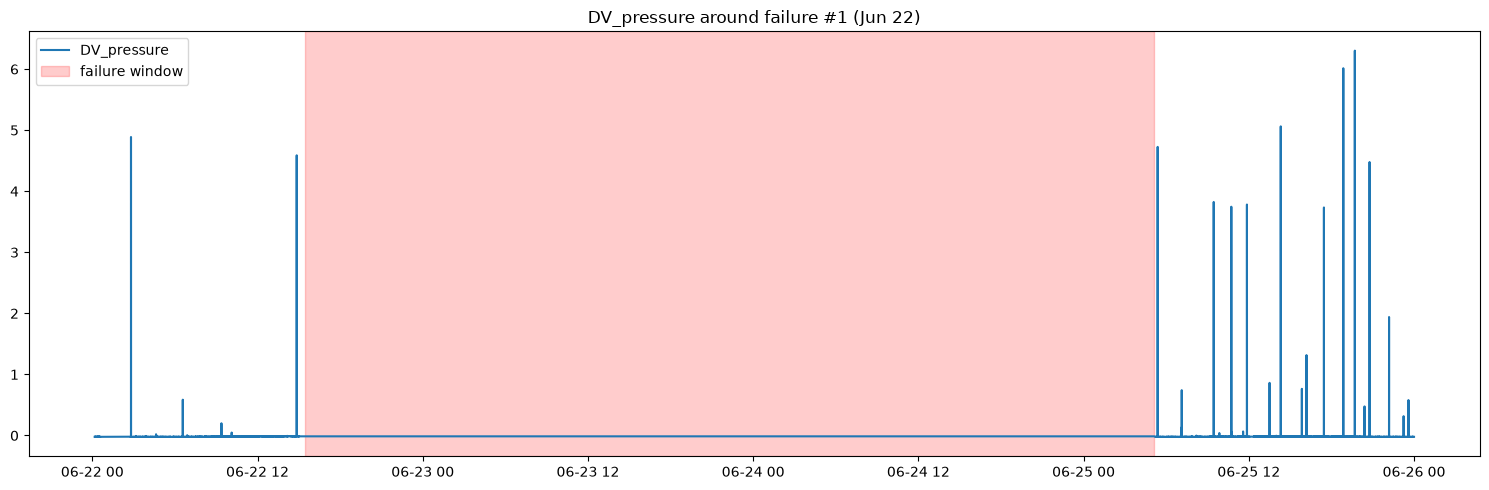

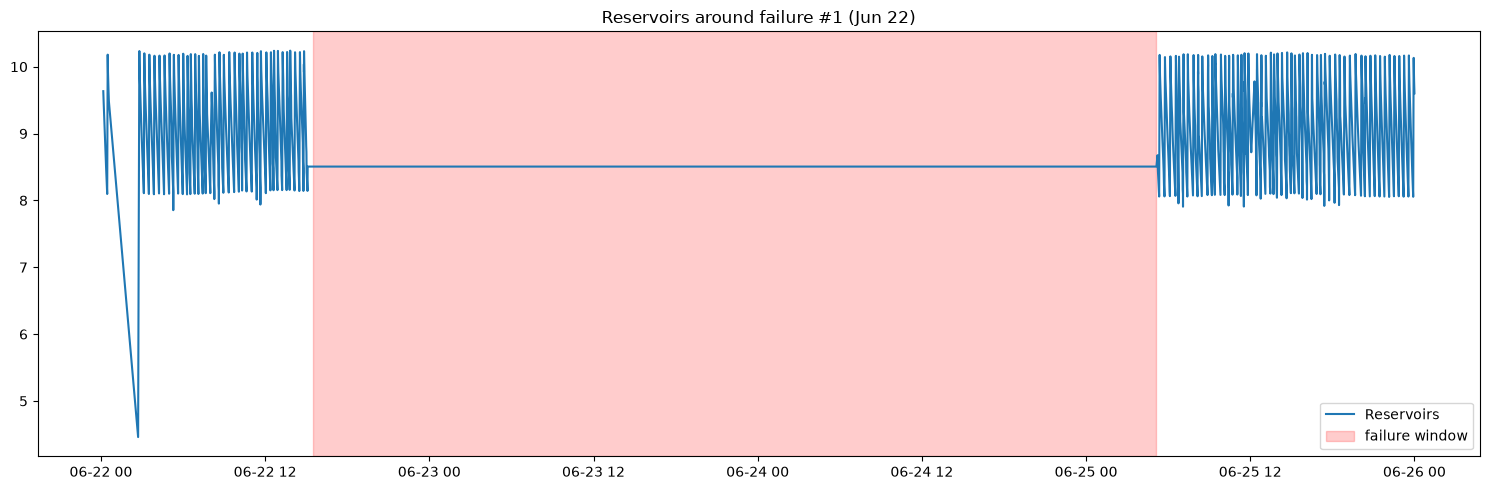

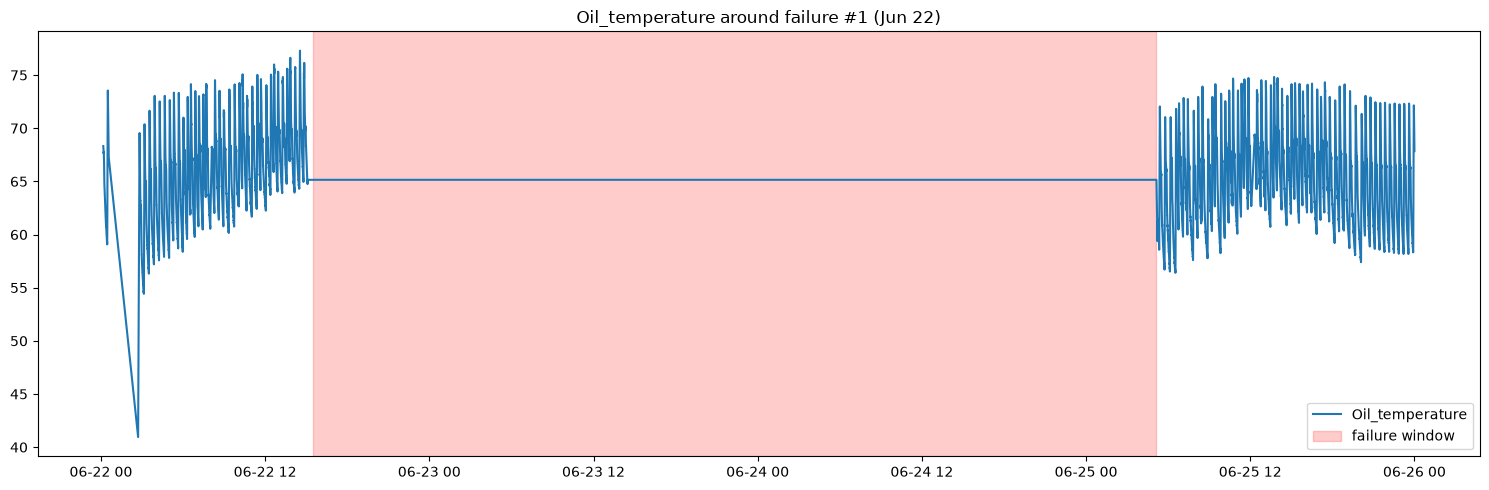

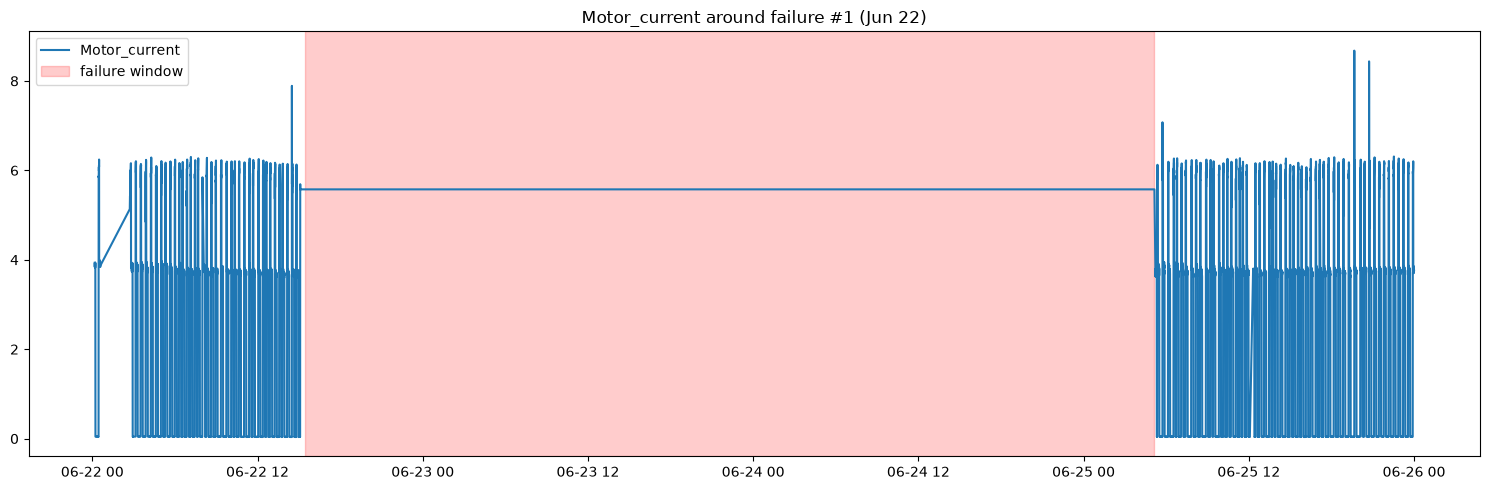

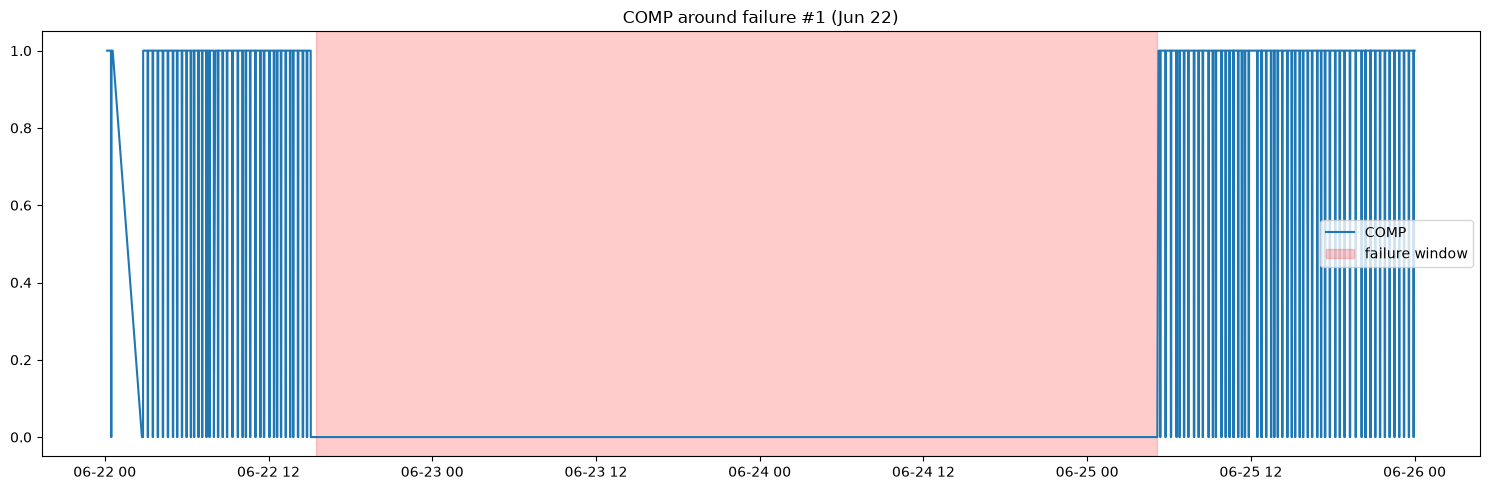

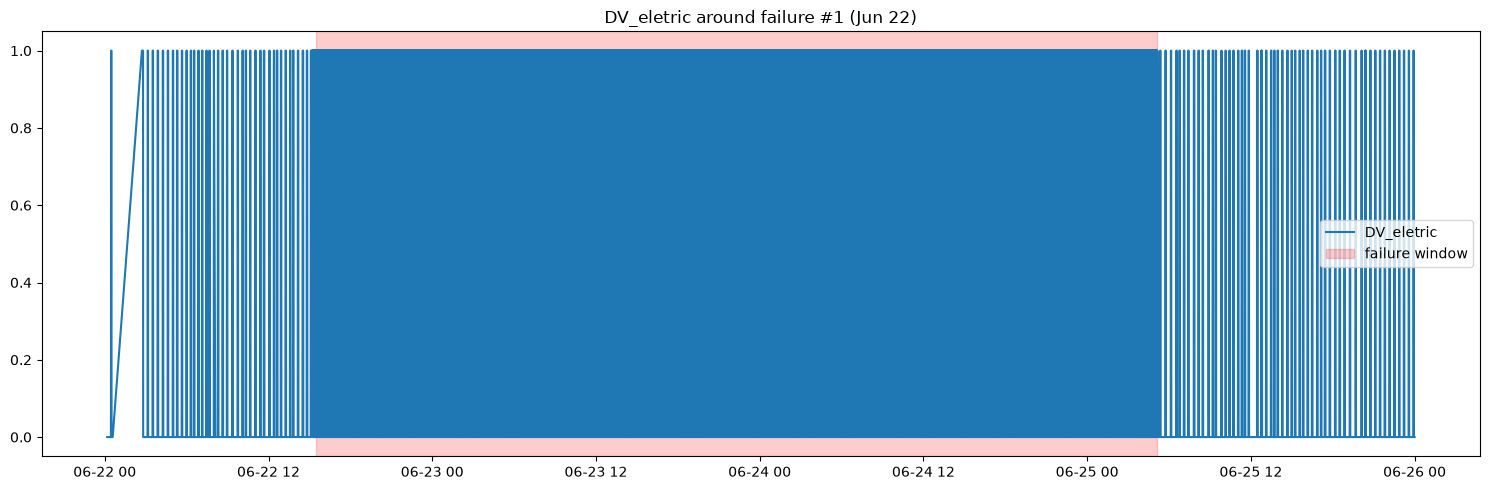

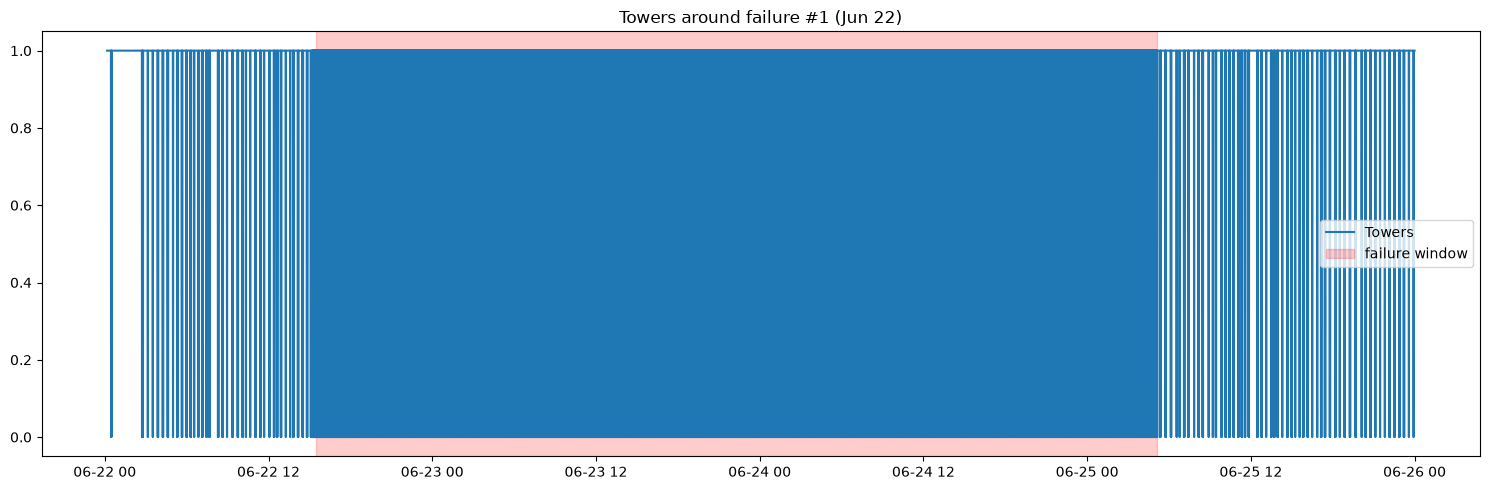

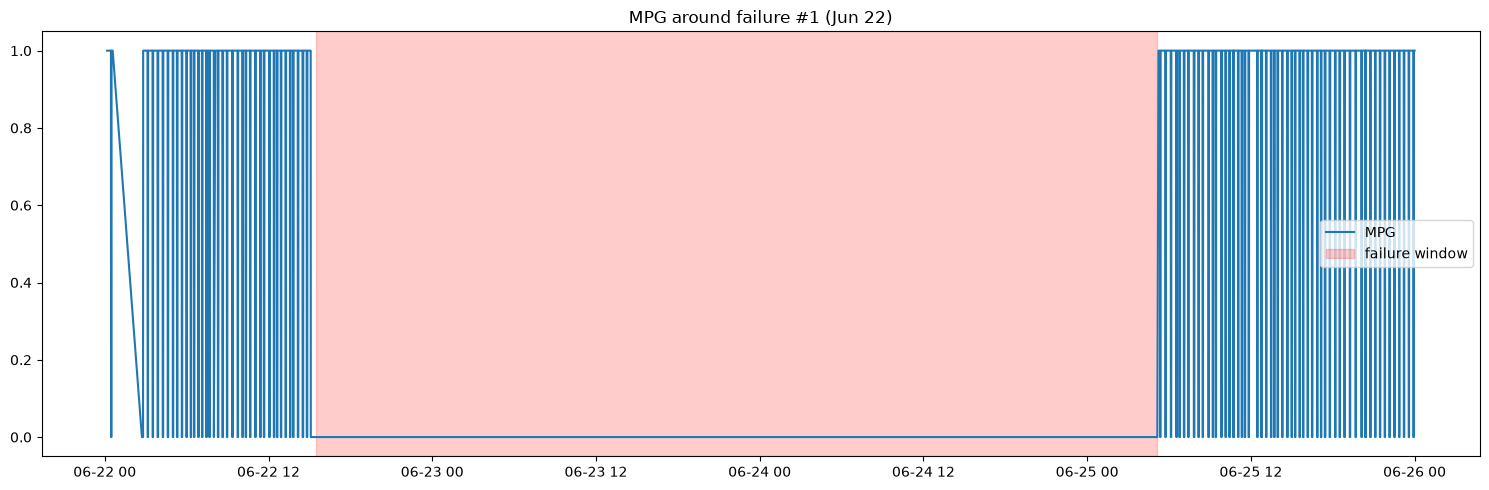

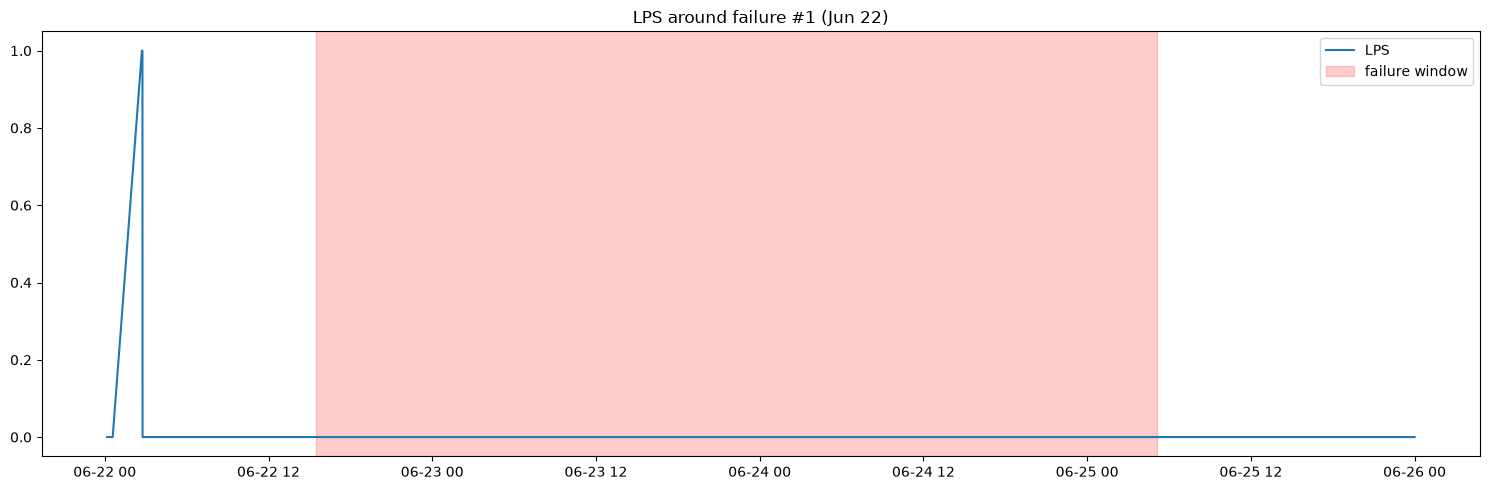

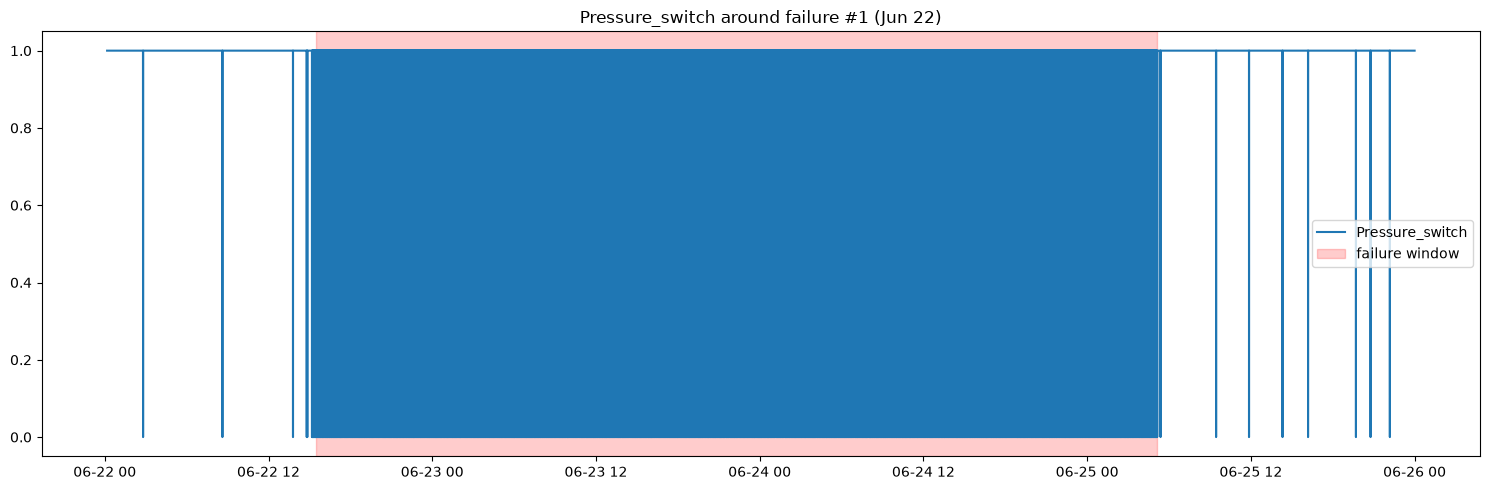

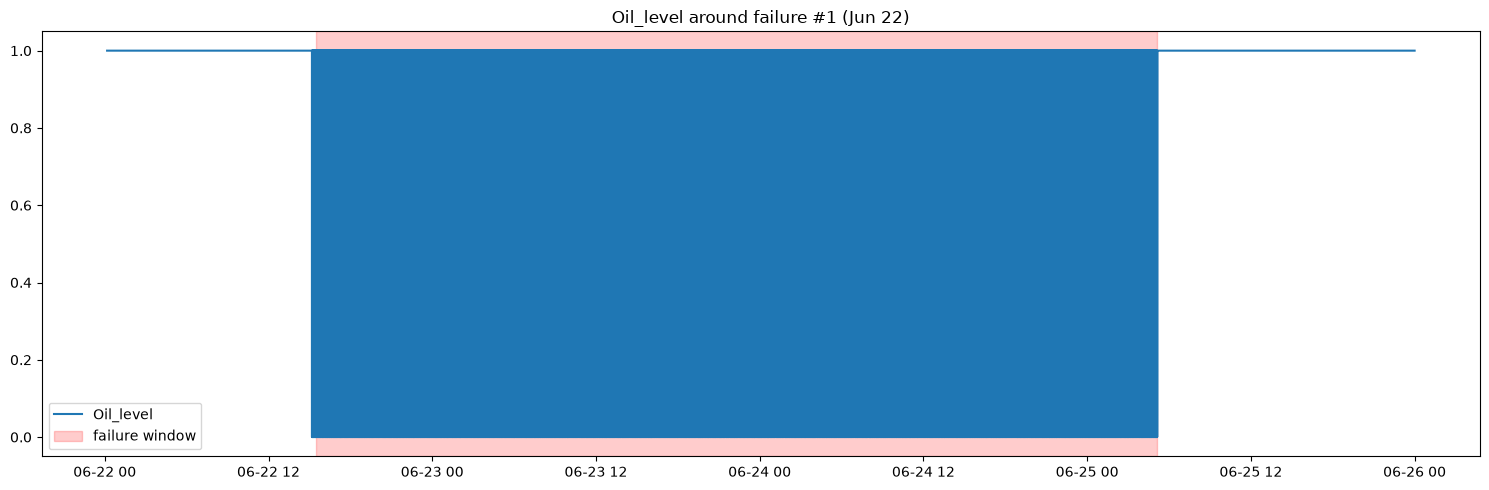

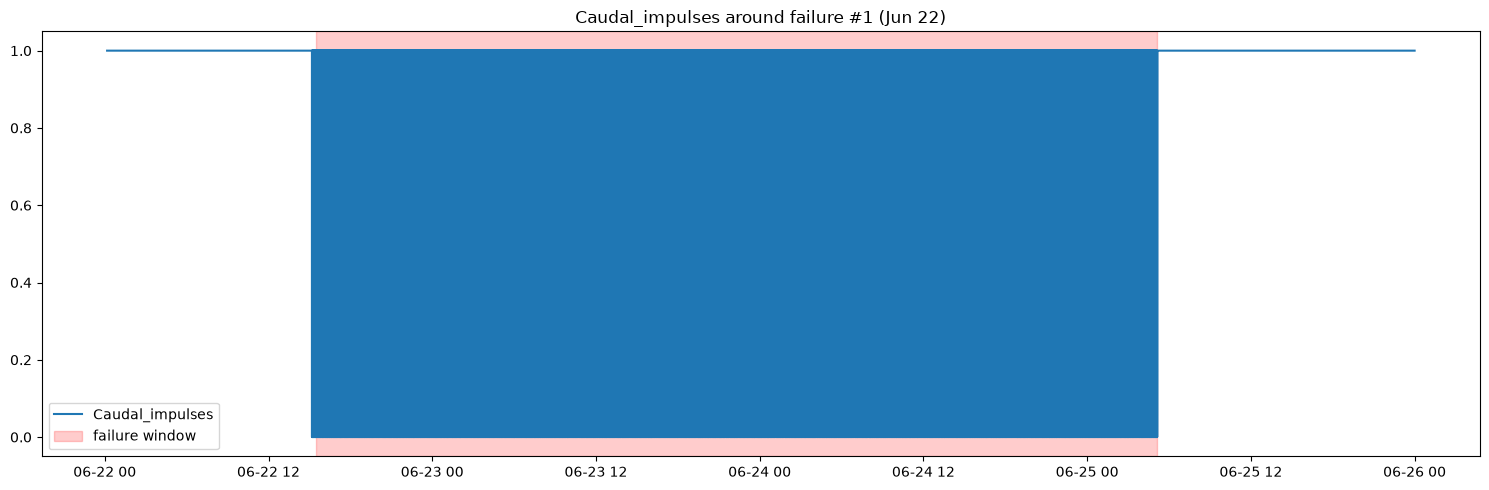

In [38]:
df_temp = df.loc['2020-06-22':'2020-06-25']

failure_start = pd.Timestamp('2020-06-22 15:28:00')
failure_end = pd.Timestamp('2020-06-25 05:08:00')

for col in df_temp.columns:
    if col != 'timestamp':
        plt.figure(figsize=(15, 5))
        plt.plot(df_temp.index, df_temp[col], label=col)
        plt.axvspan(failure_start, failure_end, color='red', alpha=0.2, label='failure window')
        plt.title(f'{col} around failure #1 (Jun 22)')
        plt.legend()
        plt.tight_layout()
        plt.show()

### 7. Jun 22–25 episode: real anomaly or data-gap artifact?

The Isolation Forest flagged **2020-06-22 15:28 → 2020-06-25 05:08** as the single longest anomaly episode (~62.5 hours). That's suspicious for two reasons: it's a huge outlier in duration compared to the other episodes, and Section 3 already showed that data gaps can masquerade as anomalies.

In [39]:
# --- Step 1: Pin down the episode window
longest_episode = episodes.iloc[0]
ep_start = longest_episode['start']
ep_end = longest_episode['end']

print(f"Investigating episode: {ep_start}  ->  {ep_end}")
print(f"Duration: {ep_end - ep_start}")

Investigating episode: 2020-06-22 15:28:00  ->  2020-06-25 05:08:00
Duration: 2 days 13:40:00


In [40]:
# --- Step 2: Does this window overlap any gap we already found in Section 3?
# `df_gaps` only contains gaps bigger than the 1-hour threshold used earlier, so this checks for the "big, obvious" gap case first.
gap_overlap = df_gaps[
    (df_gaps['gap_start'] <= ep_end) & (df_gaps['gap_end'] >= ep_start)
]

print(f"Known gaps (>1h) overlapping this episode: {len(gap_overlap)}")
gap_overlap

Known gaps (>1h) overlapping this episode: 0


,gap_start,gap_end,gap_size


In [41]:
# --- Step 3: Look for SMALLER gaps too, directly inside the window
expected_minutes = pd.date_range(start=ep_start, end=ep_end, freq='1min')
actual_minutes = df_resampled.loc[ep_start:ep_end].index

missing_minutes = expected_minutes.difference(actual_minutes)

print(f"Expected minutes in window: {len(expected_minutes)}")
print(f"Actual minutes present:    {len(actual_minutes)}")
print(f"Missing minutes:           {len(missing_minutes)}")

if len(missing_minutes) > 0:
    print("\nFirst few missing timestamps:")
    print(missing_minutes[:10])

Expected minutes in window: 3701
Actual minutes present:    3701
Missing minutes:           0


In [42]:
# --- Step 4: Check the raw (un-resampled) data for gaps inside this window
raw_window = df.loc[ep_start:ep_end]
raw_time_diffs = raw_window.index.to_series().diff()

print("Raw timestamp gap stats within the window:")
print(raw_time_diffs.describe())

print("\nLargest raw gaps found inside the window:")
print(raw_time_diffs.sort_values(ascending=False).head(10))

Raw timestamp gap stats within the window:
count                     18398
mean     0 days 00:00:12.066094
std      0 days 00:00:00.492793
min             0 days 00:00:10
25%             0 days 00:00:12
50%             0 days 00:00:12
75%             0 days 00:00:12
max             0 days 00:00:23
Name: timestamp, dtype: object

Largest raw gaps found inside the window:
timestamp
2020-06-23 02:56:23   0 days 00:00:23
2020-06-22 19:21:22   0 days 00:00:14
2020-06-22 15:28:20   0 days 00:00:13
2020-06-24 14:51:27   0 days 00:00:13
2020-06-24 14:49:02   0 days 00:00:13
2020-06-23 06:57:57   0 days 00:00:13
2020-06-24 14:50:14   0 days 00:00:13
2020-06-23 06:56:45   0 days 00:00:13
2020-06-23 06:55:44   0 days 00:00:13
2020-06-23 06:54:32   0 days 00:00:13
Name: timestamp, dtype: timedelta64[us]


In [43]:
# --- Step 5: Are the sensors "flat" (frozen) during this window?
# A dead/disconnected sensor typically holds its last value, so its variance collapses toward 0. 
# A genuine mechanical anomaly, by contrast, usually still has real (if abnormal) sensor movement. 
# Compare the std of each sensor inside the window to its std over the whole dataset as a baseline.

feature_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']

window_std = raw_window[feature_cols].std()
baseline_std = df[feature_cols].std()  # whole-dataset std, for comparison

std_comparison = pd.DataFrame({
    'std_in_window': window_std,
    'std_whole_dataset': baseline_std,
})
std_comparison['ratio'] = std_comparison['std_in_window'] / std_comparison['std_whole_dataset']

std_comparison
# A ratio near 0 means "this sensor moved far less during the episode than it does normally"; a ratio near 1 means "normal amount of movement."


,std_in_window,std_whole_dataset,ratio
TP2,0.0000000000,3.2509296807,0.0000000000
TP3,0.0000000000,0.6390950863,0.0000000000
H1,0.0000000000,3.3331995653,0.0000000000
DV_pressure,0.0000000000,0.3824015460,0.0000000000
Reservoirs,0.0000000000,0.6383070419,0.0000000000
Oil_temperature,0.0000000000,6.5162610894,0.0000000000
Motor_current,0.0000000000,2.3020534139,0.0000000000


In [44]:
## --- Step 6: How often does each sensor repeat the EXACT same value?
# Real sensor noise means consecutive readings are almost never identical.
# A frozen/dead sensor repeats its last reading over and over, so a high "percent unchanged" is a simple, direct tell for a data-gap/dropout artifact rather than a genuine anomaly.
pct_unchanged = (raw_window[feature_cols].diff() == 0).mean() * 100
pct_unchanged.rename('pct_consecutive_values_unchanged')

TP2               99.9945649220
TP3               99.9945649220
H1                99.9945649220
DV_pressure       99.9945649220
Reservoirs        99.9945649220
Oil_temperature   99.9945649220
Motor_current     99.9945649220
Name: pct_consecutive_values_unchanged, dtype: float64

No missing timestamps, but sensors look frozen -> likely a sensor dropout that still logged values, rather than a genuine mechanical anomaly

### 8. Exclude Flat Windows from the Episodes Table

In [45]:
# Flag frozen episodes using an absolute std threshold
feature_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']

# A sensor with std below this, in its own raw units, is effectively frozen 
FROZEN_STD_THRESHOLD = 1e-8

episode_rows = []

for i in range(len(episodes)):
    ep = episodes.iloc[i]
    ep_start, ep_end = ep['start'], ep['end']

    raw_window = df.loc[ep_start:ep_end]
    window_std = raw_window[feature_cols].std()
    pct_unchanged = (raw_window[feature_cols].diff() == 0).mean() * 100

    is_flat = window_std < FROZEN_STD_THRESHOLD
    mostly_flat = is_flat.sum() >= len(feature_cols) / 2
    mostly_frozen = (pct_unchanged > 90).sum() >= len(feature_cols) / 2

    episode_rows.append({
        'start': ep_start,
        'end': ep_end,
        'duration_rows': ep['duration_rows'],
        'n_flat_sensors': int(is_flat.sum()),
        'mean_pct_unchanged': pct_unchanged.mean(),
        'is_frozen_window': bool(mostly_flat or mostly_frozen),
    })

episodes_frozen_check = pd.DataFrame(episode_rows)
episodes_frozen_check

,start,end,duration_rows,n_flat_sensors,mean_pct_unchanged,is_frozen_window
0,2020-06-22 15:28:00,2020-06-25 05:08:00,3701,7,99.9945649220,True
1,2020-06-05 09:51:00,2020-06-08 14:48:00,2785,0,12.0090752621,False
2,2020-05-26 09:42:00,2020-05-28 03:16:00,2427,7,99.9918910152,True
3,2020-04-17 09:47:00,2020-04-19 03:44:00,2366,0,38.4235055724,False
4,2020-05-19 22:23:00,2020-05-21 06:57:00,1290,0,11.2130980658,False
...,...,...,...,...,...,...
733,2020-07-30 10:52:00,2020-07-30 10:52:00,1,0,NaN,False
734,2020-07-30 10:54:00,2020-07-30 10:54:00,1,0,NaN,False
735,2020-03-03 15:09:00,2020-03-03 15:09:00,1,0,NaN,False
736,2020-07-30 16:25:00,2020-07-30 16:25:00,1,0,0.0000000000,False


In [51]:
df_frozen = episodes_frozen_check[episodes_frozen_check['is_frozen_window']==True].copy()

In [58]:
df_for_pca.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
timestamp,,,,,,,,,,,,,,,,
2020-02-01 00:00:00,2020-02-01 00:00:00,-0.0122857143,9.3274285714,9.3111428571,-0.0228571429,9.3280000000,53.5214285714,0.0403571429,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
2020-02-01 00:01:00,2020-02-01 00:01:00,-0.0130000000,9.2600000000,9.2433333333,-0.0233333333,9.2596666667,53.4208333333,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
2020-02-01 00:02:00,2020-02-01 00:02:00,-0.0126666667,9.1983333333,9.1820000000,-0.0223333333,9.1990000000,53.3250000000,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
2020-02-01 00:03:00,2020-02-01 00:03:00,-0.0123333333,9.1366666667,9.1206666667,-0.0226666667,9.1366666667,53.2000000000,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000
2020-02-01 00:04:00,2020-02-01 00:04:00,-0.0130000000,9.0756666667,9.0600000000,-0.0230000000,9.0756666667,53.1291666667,0.0400000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,1.0000000000,1.0000000000,1.0000000000


In [59]:
frozen = pd.Series(False, index=df_for_pca.index)


for _, fail in df_frozen.iterrows():
    frozen |= (df_for_pca.index >= fail['start']) & (df_for_pca.index <= fail['end'])

df_clean_baseline = df_for_pca[~frozen]

In [60]:
df_for_pca.shape

(247760, 16)

In [61]:
df_clean_baseline.shape

(238996, 16)

In [62]:
window = pd.Timedelta(hours=1)

feature_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']
digital_cols = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

rolling_features = pd.DataFrame(index=df_clean_baseline.index)

for col in feature_cols:
    rolling_features[f'{col}_mean'] = df_clean_baseline[col].rolling(window, min_periods=60).mean()
    rolling_features[f'{col}_std'] = df_clean_baseline[col].rolling(window, min_periods=60).std()

for col in digital_cols:
    rolling_features[f'{col}_activity'] = df_clean_baseline[col].rolling(window, min_periods=60).mean()

rolling_features_clean = rolling_features.dropna()

In [64]:
frozen = pd.Series(False, index=df_resampled.index)

for _, fail in df_frozen.iterrows():
    frozen |= (df_resampled.index >= fail['start']) & (df_resampled.index <= fail['end'])

df_clean_resampled = df_resampled[~frozen]

In [65]:
window = pd.Timedelta(hours=1)

feature_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']
digital_cols = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

rolling_features_all = pd.DataFrame(index=df_clean_resampled.index)

for col in feature_cols:
    rolling_features_all[f'{col}_mean'] = df_clean_resampled[col].rolling(window, min_periods=60).mean()
    rolling_features_all[f'{col}_std'] = df_clean_resampled[col].rolling(window, min_periods=60).std()

for col in digital_cols:
    rolling_features_all[f'{col}_activity'] = df_clean_resampled[col].rolling(window, min_periods=60).mean()

rolling_features_all_clean = rolling_features_all.dropna()

In [66]:
pipe = Pipeline([('scaler', StandardScaler()), ('reducer', PCA(n_components=0.9))])

pipe.fit(rolling_features_clean)  # normal baseline data

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('reducer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['TP2_mean','TP2_std','TP3_mean',...,'Pressure_switch_activity', 'Oil_level_activity','Caudal_impulses_activity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [67]:
# Version for scoring later: gaps out, failures still in
transformed_all_clean = pipe.transform(rolling_features_all_clean)

# Also keep the transformed "normal-only" version — you'll need this next,
# to fit Isolation Forest only on normal behavior
transformed_normal_clean = pipe.transform(rolling_features_clean)

In [68]:
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
iso_forest.fit(transformed_normal_clean)

# Score everything, including the failure periods
anomaly_labels = iso_forest.predict(transformed_all_clean)       # -1 = anomaly, 1 = normal
anomaly_scores = iso_forest.decision_function(transformed_all_clean)  # continuous score; lower = more anomalous

In [69]:
rolling_features_all_clean['anomaly_label'] = anomaly_labels
rolling_features_all_clean['anomaly_score'] = anomaly_scores

In [ ]:
print(len(rolling_features_all_clean[rolling_features_all_clean['anomaly_label'] == -1]))
print(len(rolling_features_all_clean))

print(len(rolling_features_all_clean[rolling_features_all_clean['anomaly_label'] == -1])/(len(rolling_features_all_clean)))

26128
229038
0.11407714003789764


In [ ]:
##Dynamic Time Warping (DTW) 
# Sparse Autoencoder trained only on "normal" data
# A related, simpler approach:  4 known failures as templates, and scan the rest of the dataset with a sliding window, computing DTW distance (or feature-vector distance) from each window to the nearest known-failure template — windows that

# The failures typically are undetectable according to traditional maintenance criteria (predefined thresholds)." That's their own stated reason for building this as a machine-learning benchmark in the first place — simple threshold-crossing rules don't reliably catch these failures. So there isn't an industry-standard threshold you're missing that would make this easy; the difficulty you've been experiencing (needing behavioral/pattern-based features rather than simple value thresholds) is the actual documented nature of the problem, not a gap in your approach.
# three key open research lines for the PdM domain: failure prediction, remaining useful life (RUL), and root cause analyses (RCA).